In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [15]:
df=pd.read_csv("ROC_AUC_Customer_Churn_Dataset.csv")

In [16]:
df.describe

<bound method NDFrame.describe of    Customer_ID  Age  Monthly_Spend  Tenure_Months  Churn
0         C001   22           1200              3      1
1         C002   35            800             24      0
2         C003   28           1500              6      1
3         C004   42            700             36      0
4         C005   25           1300              5      1
5         C006   31            900             18      0
6         C007   45            600             48      0
7         C008   26           1400              4      1
8         C009   38            850             30      0
9         C010   29           1250              8      1
10        C011   41            750             40      0
11        C012   24           1600              2      1
12        C013   33            950             20      0
13        C014   27           1350              7      1
14        C015   48            650             52      0
15        C016   30           1100             12     

In [17]:
df.head()

,Customer_ID,Age,Monthly_Spend,Tenure_Months,Churn
0,C001,22,1200,3,1
1,C002,35,800,24,0
2,C003,28,1500,6,1
3,C004,42,700,36,0
4,C005,25,1300,5,1


In [18]:
df.tail()

,Customer_ID,Age,Monthly_Spend,Tenure_Months,Churn
25,C026,21,1700,1,1
26,C027,40,810,27,0
27,C028,28,1320,6,1
28,C029,43,730,39,0
29,C030,36,880,25,0


In [19]:
df.isnull().sum()

Customer_ID      0
Age              0
Monthly_Spend    0
Tenure_Months    0
Churn            0
dtype: int64

In [20]:
num_data=df.select_dtypes('int64','float64')

In [21]:
num_data.head()

,Age,Monthly_Spend,Tenure_Months,Churn
0,22,1200,3,1
1,35,800,24,0
2,28,1500,6,1
3,42,700,36,0
4,25,1300,5,1


In [27]:
from scipy.stats import skew


0.21187342754867292
0.41515513901395673
0.4360739731525281
0.2690691175985249


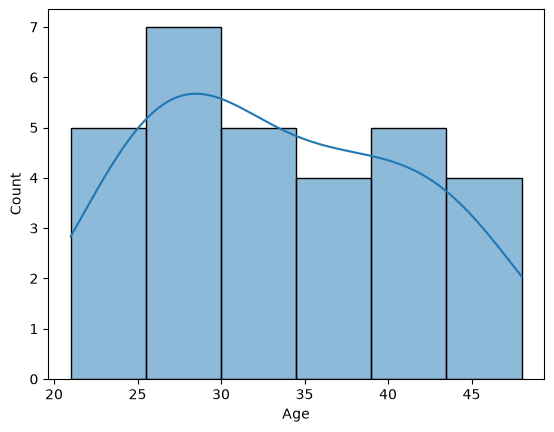

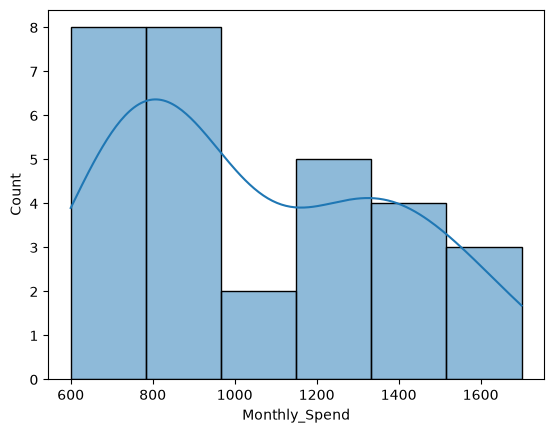

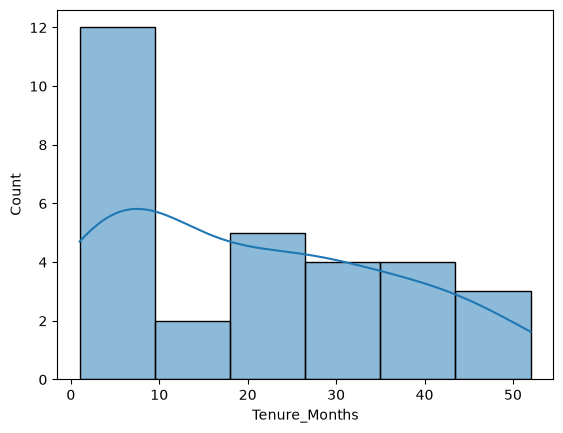

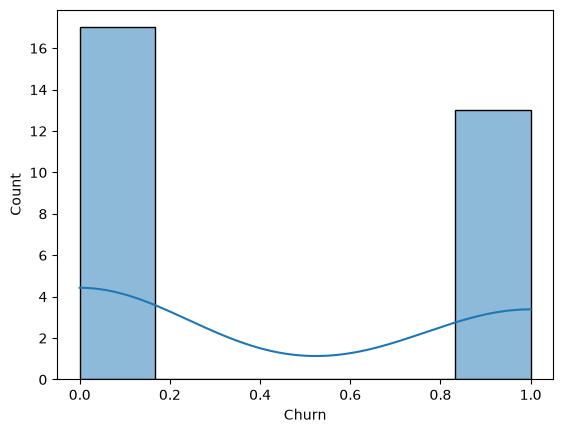

In [29]:
for i in num_data:
    plt.figure()
    sns.histplot(num_data[i],kde=True)
    print(skew(num_data[i]))

In [41]:
# Seperate dependent and independent features
X=df[['Age','Monthly_Spend','Tenure_Months']]
Y=df.iloc[:,-1]


In [42]:
# train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [43]:
# Create an object of logistic regression
lr=LogisticRegression()

In [44]:
lr.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [45]:
#Checking Training Score
lr.score(X_train,Y_train)

1.0

In [46]:
lr.score(X_test,Y_test)

0.8333333333333334

In [65]:
#Find probability of positive class of testing data
y_prob=lr.predict_proba(X_test)[:,1]


In [66]:
y_prob

array([9.99999966e-01, 4.91268003e-01, 4.28695224e-15, 1.00000000e+00,
       2.80387107e-09, 9.99991791e-01])

In [67]:
from sklearn.metrics import roc_auc_score,roc_curve

In [68]:
roc=roc_auc_score(Y_test,y_prob)

In [69]:
roc

1.0

precision vs percentange


In [70]:
fpr,tpr,th=roc_curve(Y_test,y_prob)

In [75]:
print(fpr)
print(tpr)
print(th[3])

[0. 0. 0. 1.]
[0.   0.25 1.   1.  ]
4.28695224118124e-15


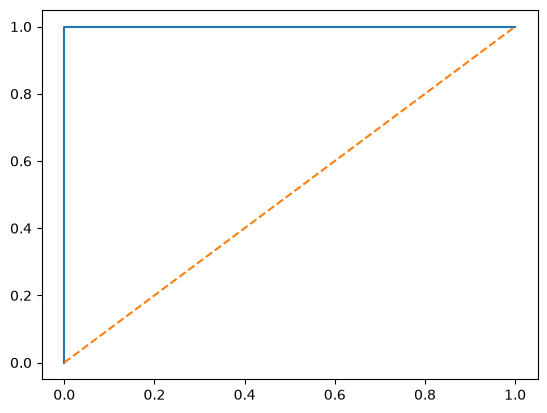

In [71]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")